In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_context('notebook')
from IPython.display import display, Audio
import soundfile as sf
import urllib
import librosa

# Ejemplos de Convolución 

## Convolución entre señales sencillas

Convolución entre dos pulsos cuadrados con la función `numpy.convolve`. Si las señales a convolucionar tienen largos $N$ y $M$, el resultado de la convolución tendrá largo $N+M-1$.

Largo de f:  2000
Largo de g:  2000
Largo de y:  3999


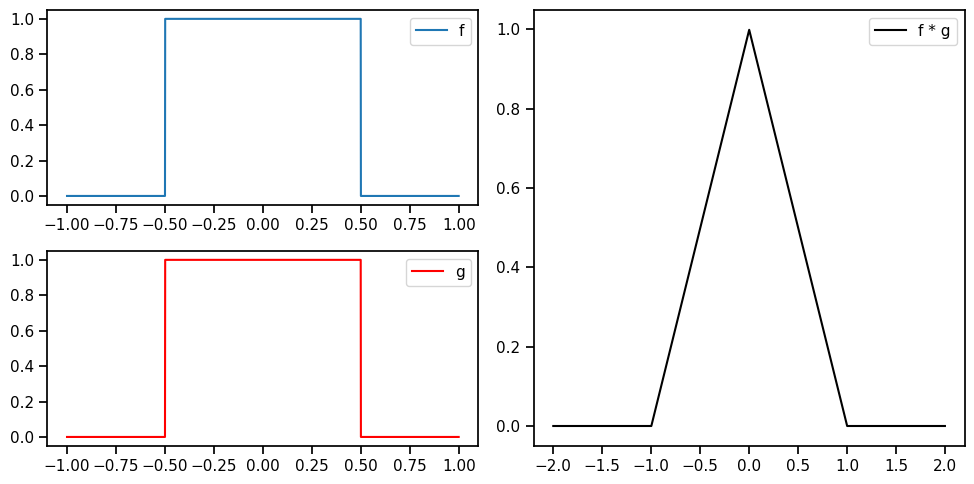

In [ ]:
sr = 1000
dur = 2.0
t = np.arange(int(dur*sr))/sr - 1

# Creamos dos señales f y g con forma de pulso cuadrado
f = np.zeros(t.shape)
mask = ( t>-0.5) & ( t<0.5 )
f[mask] = 1

g = f

plt.figure(figsize=(10,5))
plt.subplot(2,2,1)
plt.plot(t,f,label='f');
plt.legend();
plt.subplot(2,2,3)
plt.plot(t,g,'r',label='g');
plt.legend();

# Usamos la funcion convolve
y = np.convolve(f,g)/sr

print("Largo de f: ", len(f))
print("Largo de g: ", len(g))
print("Largo de y: ", len(y))

plt.subplot(1,2,2)
t = np.arange(len(y))/sr
plt.plot(t-t.mean(),y,'k',label='f * g')
plt.legend()
plt.tight_layout()
plt.show()

Convolución entre impulsos y una señal arbitraria $h[n]$ como si fuera la respuesta al impulso de un sistema LTI:

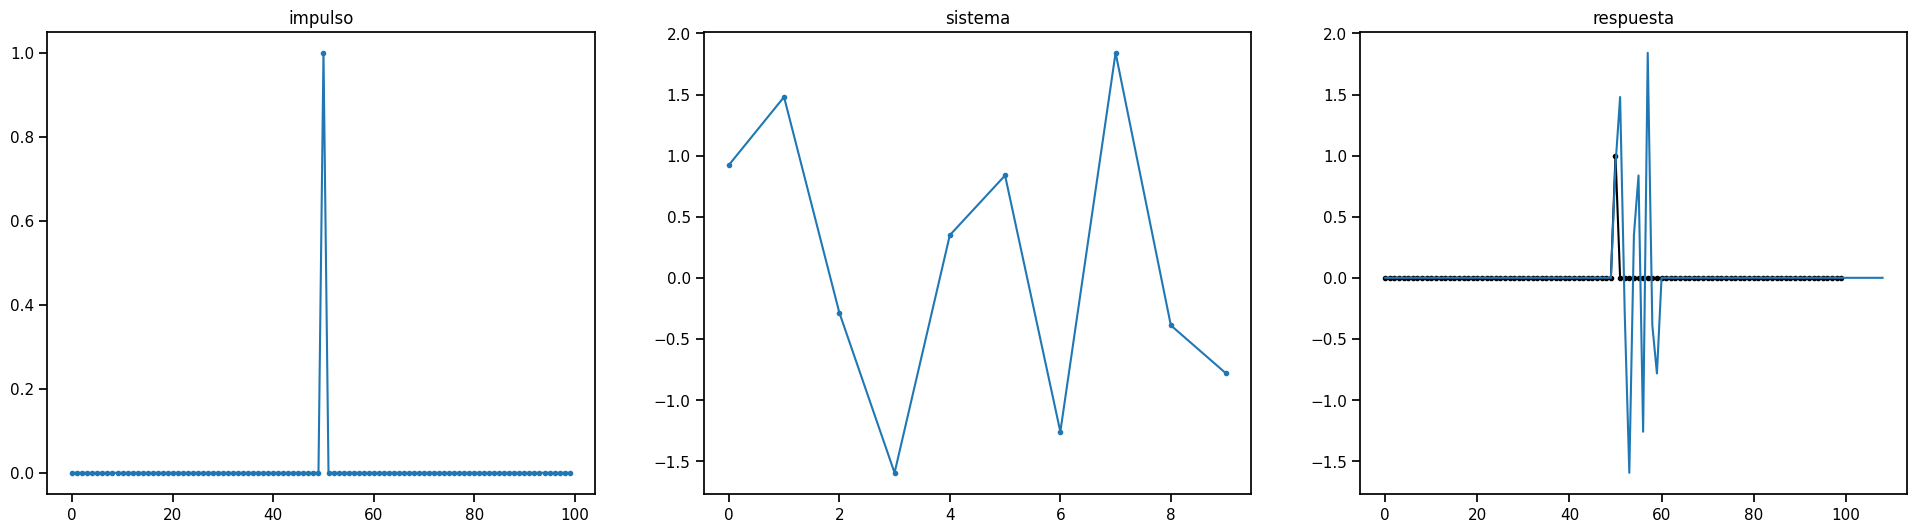

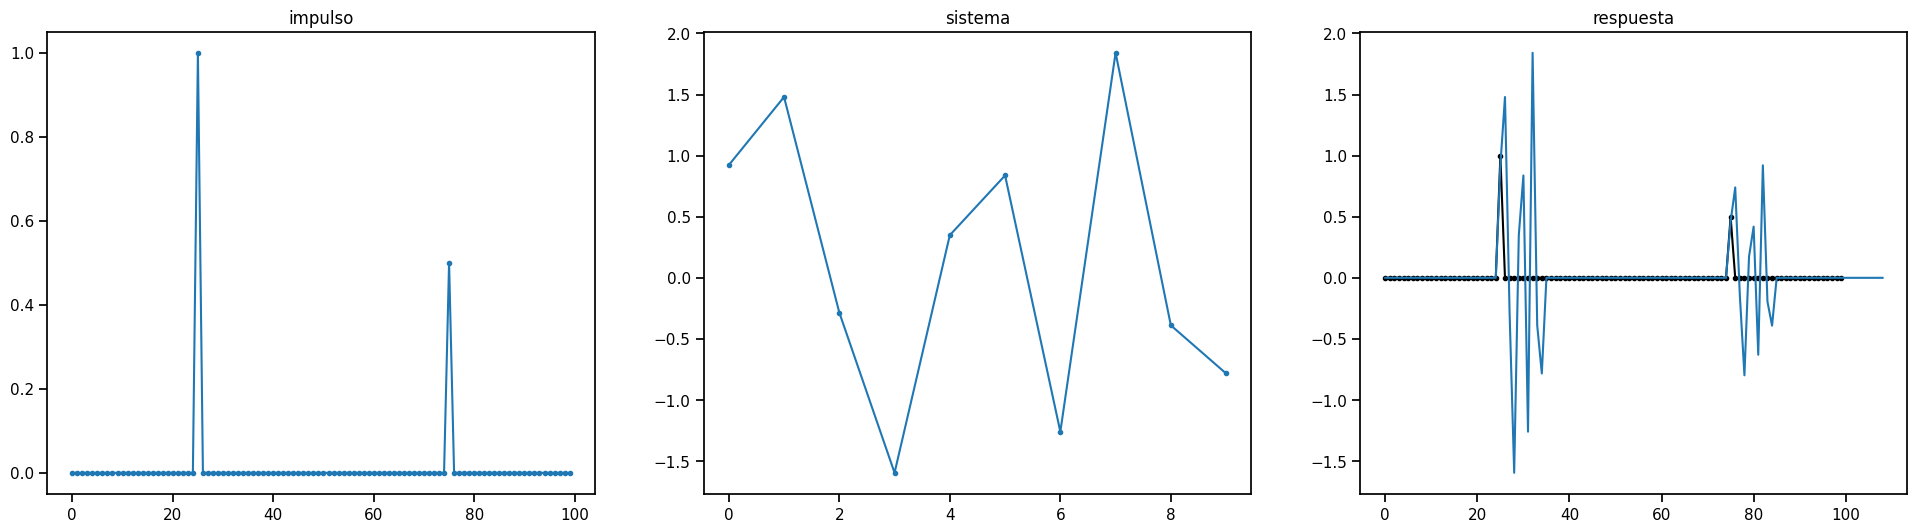

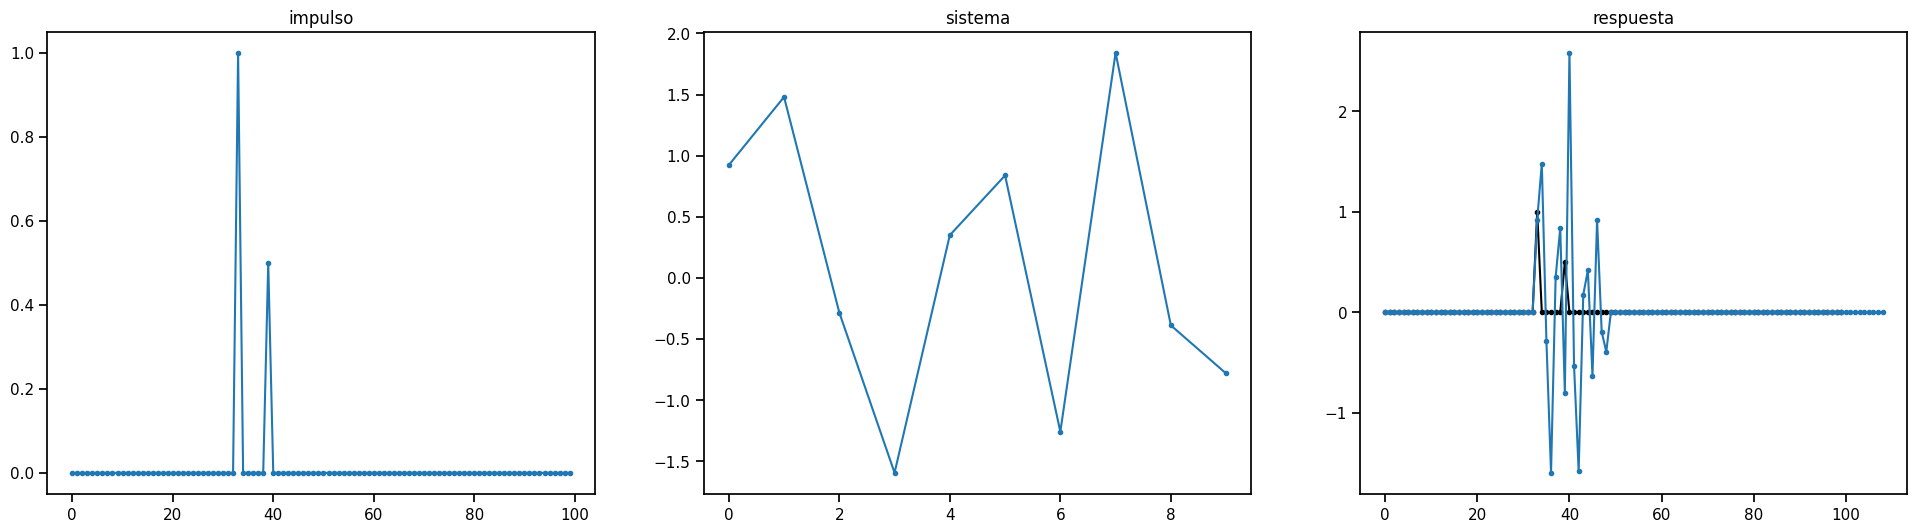

In [3]:
sr = 1000
dur = 0.1
t = np.arange(int(dur*sr))/sr

impulso = np.zeros(t.shape)
impulso[len(t)//2] = 1

# Sistema aleatorio desconocido
sistema = np.random.randn(10)

y = np.convolve(impulso, sistema)

plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.plot(impulso,'.-');
plt.title("impulso")

plt.subplot(1,3,2)
plt.plot(sistema,'.-')
plt.title("sistema")

plt.subplot(1,3,3)
plt.plot(impulso,'.-k')
plt.plot(y)
plt.title("respuesta");

sr = 1000
dur = 0.1
t = np.arange(int(dur*sr))/sr

impulso = np.zeros(t.shape)
impulso[len(t)//4] = 1
impulso[len(t)//4*3] = 0.5

y = np.convolve(impulso,sistema,'full')

plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.plot(impulso,'.-');
plt.title("impulso")

plt.subplot(1,3,2)
plt.plot(sistema,'.-')
plt.title("sistema")

plt.subplot(1,3,3)
plt.plot(impulso,'.-k')
plt.plot(y)
plt.title("respuesta");


sr = 1000
dur = 0.1
t = np.arange(int(dur*sr))/sr

impulso = np.zeros(t.shape)
impulso[len(t)//3] = 1
impulso[int(len(t)//3*1.2)] = 0.5

y = np.convolve(impulso,sistema,'full')

plt.figure(figsize=(24,6))
plt.subplot(1,3,1)
plt.plot(impulso,'.-');
plt.title("impulso")

plt.subplot(1,3,2)
plt.plot(sistema,'.-')
plt.title("sistema")

plt.subplot(1,3,3)
plt.plot(impulso,'.-k')
plt.plot(y,'.-')
plt.title("respuesta");

plt.show()

## Convolución entre audio y respuesta al impulso de una sala

Convolución entre una señal de audio y la respuesta al impulso de una sala para simular la reverberación de un espacio:

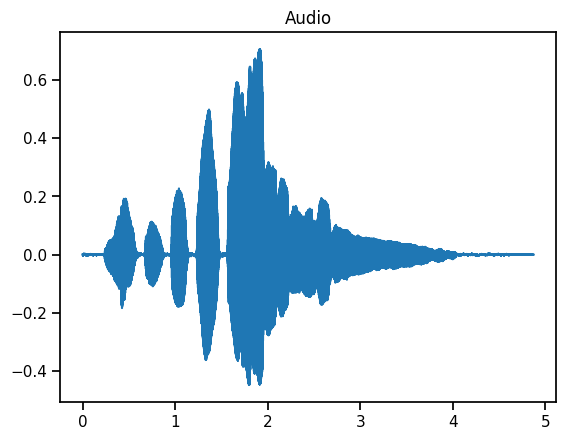

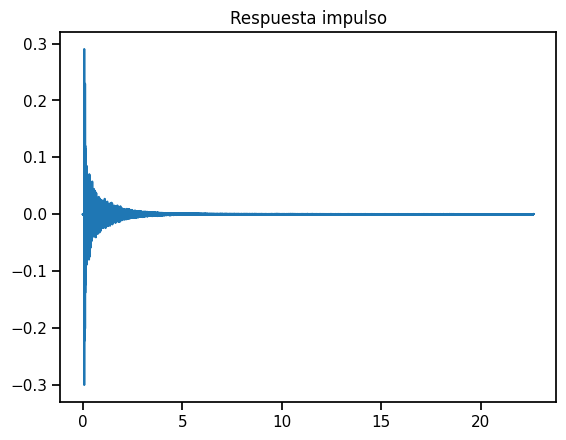

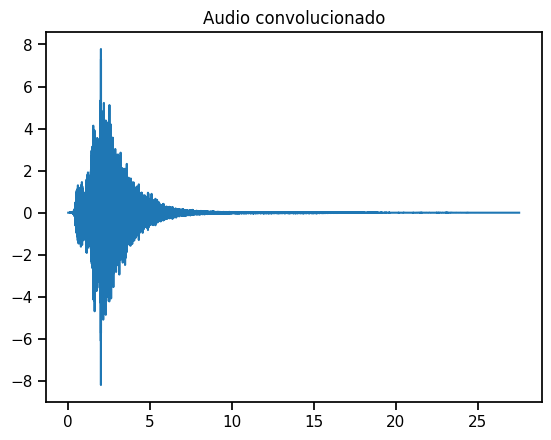

In [4]:

# Cargamos audios
sr = 44100
s, sr = librosa.load('../../assets/singing.wav',sr=sr)
t_s = np.arange(len(s))/sr
ir, sr  = librosa.load('../../assets/ir_larga.wav',sr=sr)
t_ir = np.arange(len(ir))/sr
plt.figure()
plt.plot(t_s, s)
plt.title('Audio')
plt.show()
display(Audio(s,rate=sr))
plt.figure()
plt.plot(t_ir, ir)
plt.title('Respuesta impulso');
plt.show()
display(Audio(ir,rate=sr))

# Convolución

s_conv_ir = np.convolve(s, ir) # tarda más de 20 segundos en ejecutarse
t = np.arange(len(s_conv_ir))/sr
plt.figure()
plt.plot(t, s_conv_ir)
plt.title('Audio convolucionado')
plt.show()
Audio(s_conv_ir,rate=sr)
plt.show()

## Síntesis granular con convolución

Un grano de audio es una pequeña porción de audio que se repite muchas veces. Suele tener una envolvente suave y un tamaño de unos pocos milisegundos. Podemos superponer granos facilmente utilzando la convolución. Primero elijamos un grano

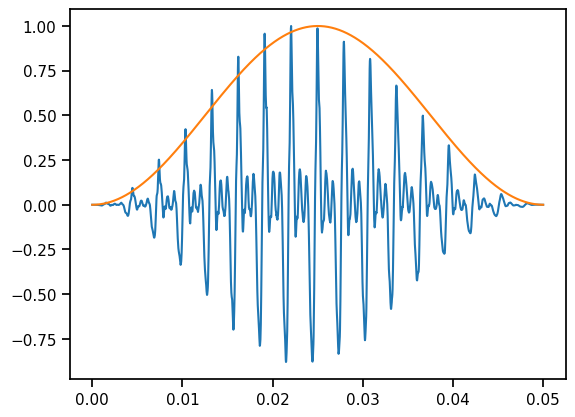

In [5]:
sr = 44100
t1 = 0.5
t2 = t1 + 0.05

grano = s[int(t1*sr):int(t2*sr)]

env = (1-np.cos(2*np.pi*np.arange(len(grano))/len(grano)))*0.5
grano = grano*env
grano = grano/np.max(np.abs(grano))

t = np.arange(len(grano))/sr
plt.plot(t,grano)
plt.plot(t,env)

Audio(grano,rate=sr)
plt.show()

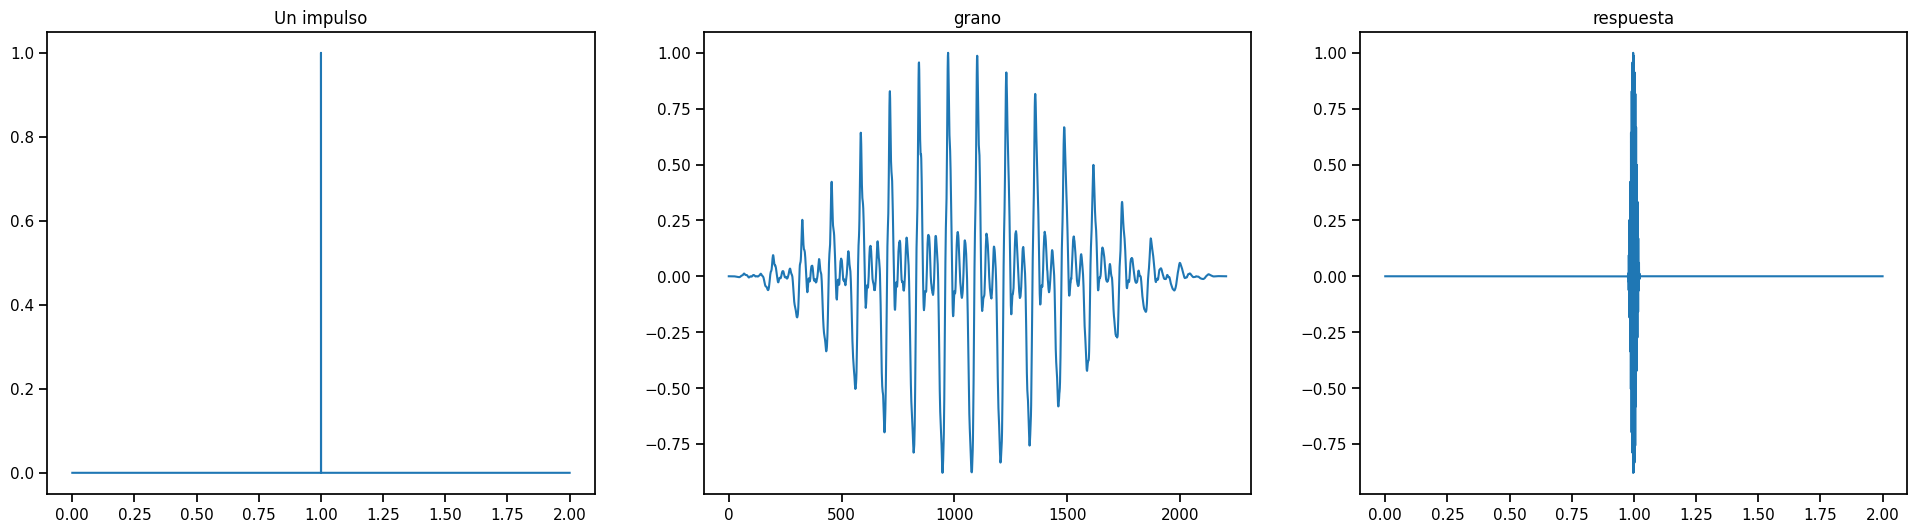

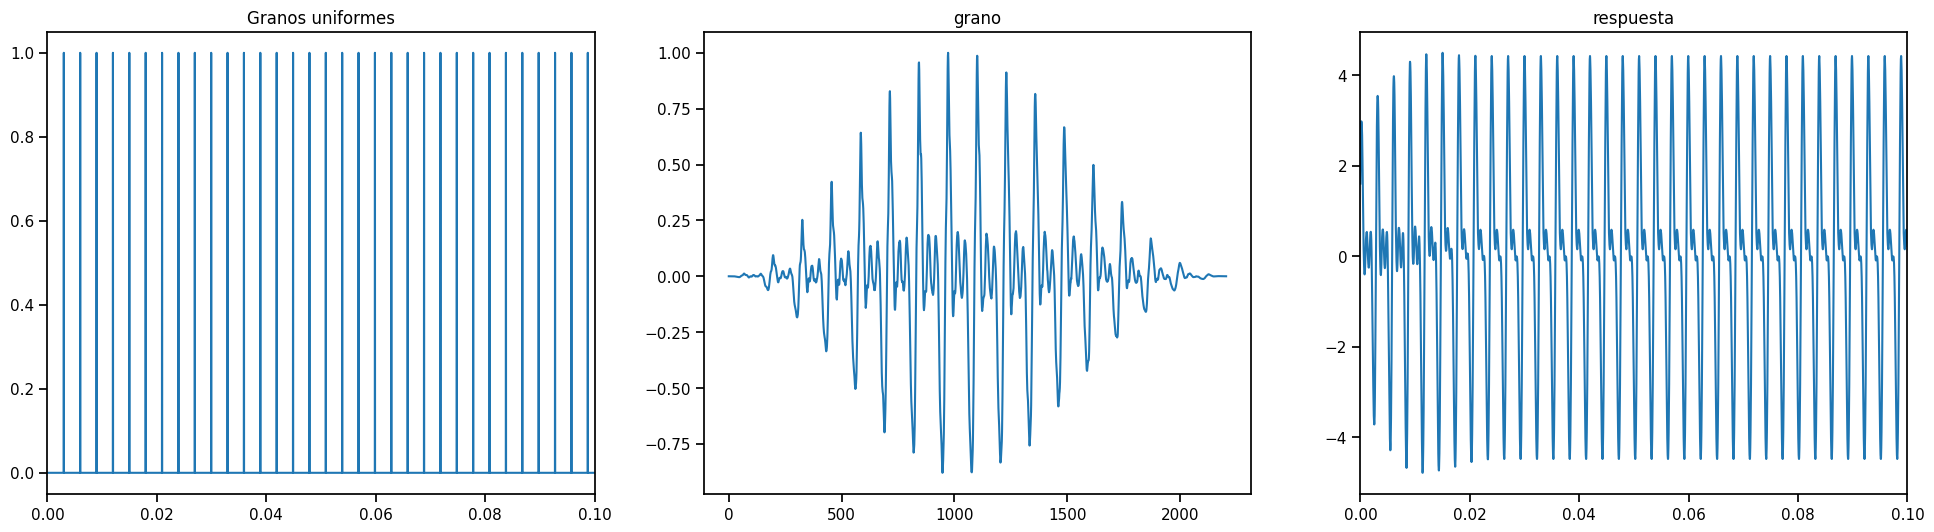

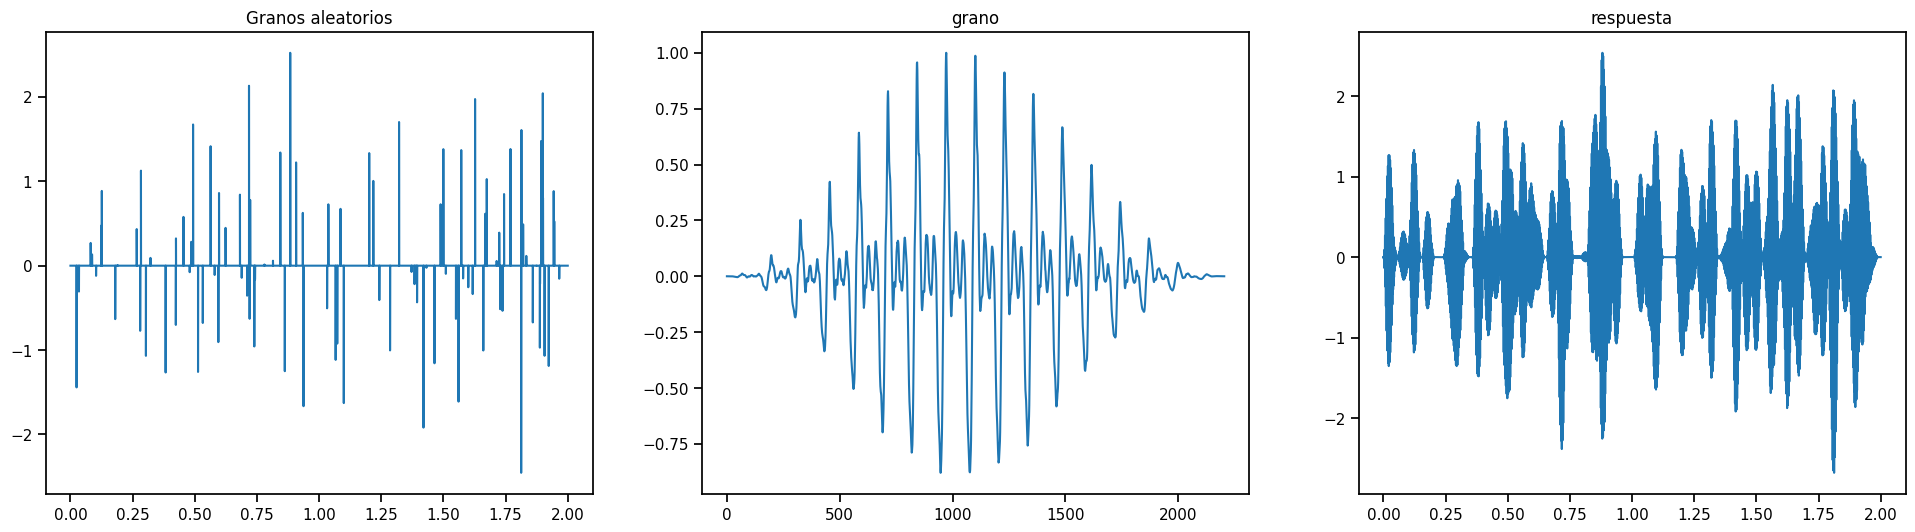

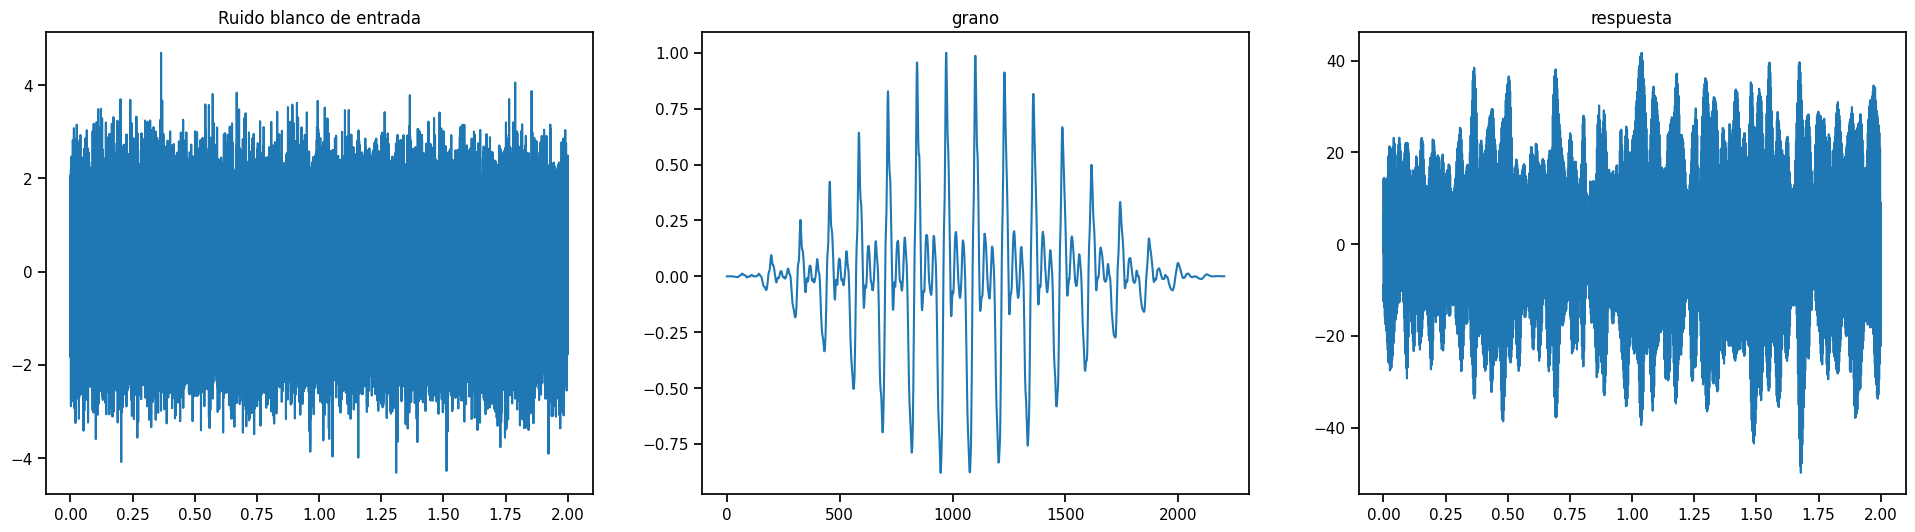

In [6]:
sr = 44100
dur = 2.0
t = np.arange(int(dur*sr))/sr
x = np.zeros(len(t))

# uno solo
x[x.size//2] = 1 

xs = []
xs.append(("Un impulso",x.copy()))

# granos uniformes

# densidad de granos por segundo
f0 = 332
step = int(sr/f0)

x = np.zeros(len(t))
x[step::step] = 1

xs.append(("Granos uniformes", x.copy()))

# granos aleatorios en tiempo y amplitud
x = np.zeros(len(t))
d = 50 # densidad de granos por segundo
N = int(dur*d)
idx = np.random.randint(0,len(t),N)
x[idx] = np.random.randn(N)

xs.append(("Granos aleatorios", x.copy()))

x = np.random.randn(len(t))

xs.append(("Ruido blanco de entrada", x.copy()))

for title, x in xs:

    y = np.convolve(x, grano,'same')

    plt.figure(figsize=(24,6))
    plt.subplot(1,3,1)
    plt.plot(t,x);
    if title == "Granos uniformes":
        plt.xlim(0,0.1)

    plt.title(title)

    plt.subplot(1,3,2)
    plt.plot(grano)
    plt.title("grano")

    plt.subplot(1,3,3)
    plt.plot(t,y)
    plt.title("respuesta");
    if title == "Granos uniformes":
        plt.xlim(0,0.1)
    display(Audio(y,rate=sr))
    plt.show()

## Correlación cruzada

## Auto-Correlación 

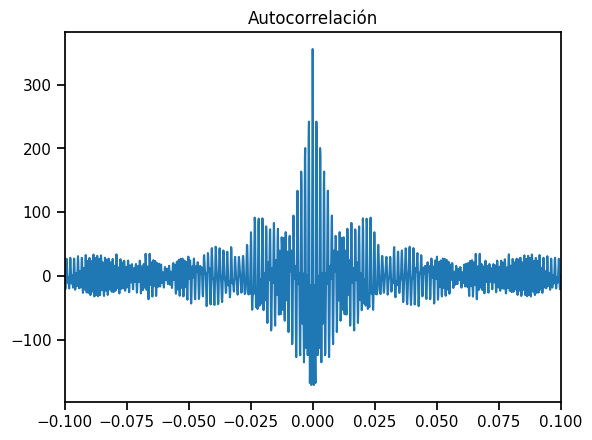

In [23]:
s, sr = librosa.load('../../assets/singing.wav',sr=8000)
z = np.correlate(s,s,mode='full')
t = np.arange(len(z))/sr-len(z)/sr/2
plt.figure()
plt.plot(t,z)
plt.xlim(-0.1,0.1)
plt.title('Autocorrelación')
plt.show()
display(Audio(z,rate=sr))

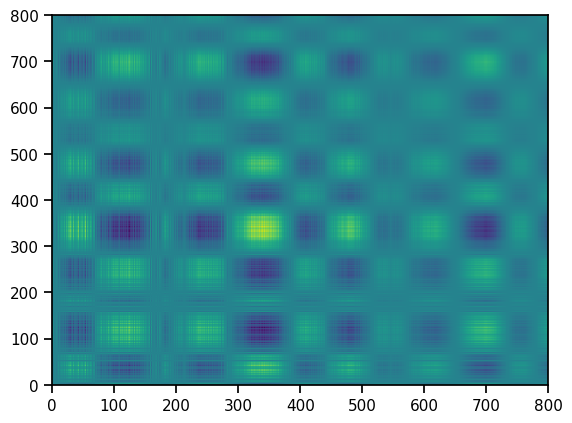

In [9]:
s, sr = librosa.load('../../assets/singing.wav',sr=8000)
s = s[:int(0.1*sr)]
# np.outer(s,s)

plt.figure()
plt.pcolor(np.outer(s,s))